In [172]:
# 데이터 분석 라이브러리
import pandas as pd

# 대량의 행렬 데이터 연산 라이브러리
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 모델링, 회귀분석
import statsmodels.api as sm

# 가설 검정
from scipy import stats

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [173]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
# Boston Housing 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/SKALA_0720종합실습/BostonHousing.csv')

df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [175]:
# 데이터의 구조 파악
print(f'행의 개수 : {df.shape[0]}')
print(f'열의 개수 : {df.shape[1]}')

행의 개수 : 506
열의 개수 : 14


In [176]:
# 데이터에 대한 요약 정보
df.info()
# xxx entries : 전체 행의 개수
# total n columns : 전체 열의 개수
# Column : 컬럼 이름 목록
# Non-Null Count : 결측치를 제외한 데이터의 개수
# Dtype : 데이터 타입

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [177]:
# 컬럼별 결측치 개수 확인
df.isna().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [178]:
# IQR을 이용한 이상치 확인 함수
def detect_outliers_iqr(data, column):
    # 제1사분위수
    q1 = data[column].quantile(0.25)

    # 제3사분위수
    q3 = data[column].quantile(0.75)

    # 사분위수 범위
    IQR = q3 - q1

    # 이상치 하한선
    lower_bound = q1 - 1.5 * IQR

    # 이상치 상한선
    upper_bound = q3 + 1.5 * IQR

    # 이상치 데이터 추출
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    print(f'극단치 상한 : {upper_bound}')
    print(f'극단치 하한 : {lower_bound}')
    print(f'극단치 개수 : {len(outliers)}')

    return lower_bound, upper_bound

# 수치형 데이터 이상치 확인
for col in [
    'crim',
    'zn',
    'indus',
    'nox',
    'rm',
    'age',
    'dis',
    'rad',
    'tax',
    'ptratio',
    'b',
    'lstat',
    'medv'] :
  print(f'name : {col}')
  detect_outliers_iqr(df, col)
  print()

name : crim
극단치 상한 : 9.06963875
극단치 하한 : -5.31051125
극단치 개수 : 66

name : zn
극단치 상한 : 31.25
극단치 하한 : -18.75
극단치 개수 : 68

name : indus
극단치 상한 : 37.465
극단치 하한 : -14.175
극단치 개수 : 0

name : nox
극단치 상한 : 0.8865
극단치 하한 : 0.18650000000000005
극단치 개수 : 0

name : rm
극단치 상한 : 7.730500000000001
극단치 하한 : 4.778499999999999
극단치 개수 : 30

name : age
극단치 상한 : 167.64999999999998
극단치 하한 : -28.54999999999999
극단치 개수 : 0

name : dis
극단치 상한 : 9.820800000000002
극단치 하한 : -2.5322000000000005
극단치 개수 : 5

name : rad
극단치 상한 : 54.0
극단치 하한 : -26.0
극단치 개수 : 0

name : tax
극단치 상한 : 1246.5
극단치 하한 : -301.5
극단치 개수 : 0

name : ptratio
극단치 상한 : 24.4
극단치 하한 : 13.199999999999998
극단치 개수 : 15

name : b
극단치 상한 : 427.49625000000003
극단치 하한 : 344.10624999999993
극단치 개수 : 77

name : lstat
극단치 상한 : 31.962500000000006
극단치 하한 : -8.057500000000005
극단치 개수 : 7

name : medv
극단치 상한 : 36.962500000000006
극단치 하한 : 5.0624999999999964
극단치 개수 : 40



In [179]:
# 범주형 데이터에 대한 이상치
# 도수분포를 통한 확인
print(df['chas'].value_counts().index)
print(df['chas'].value_counts())

# unique 함수 사용
print(np.unique(df['chas']))

Index([0, 1], dtype='int64', name='chas')
chas
0    471
1     35
Name: count, dtype: int64
[0 1]


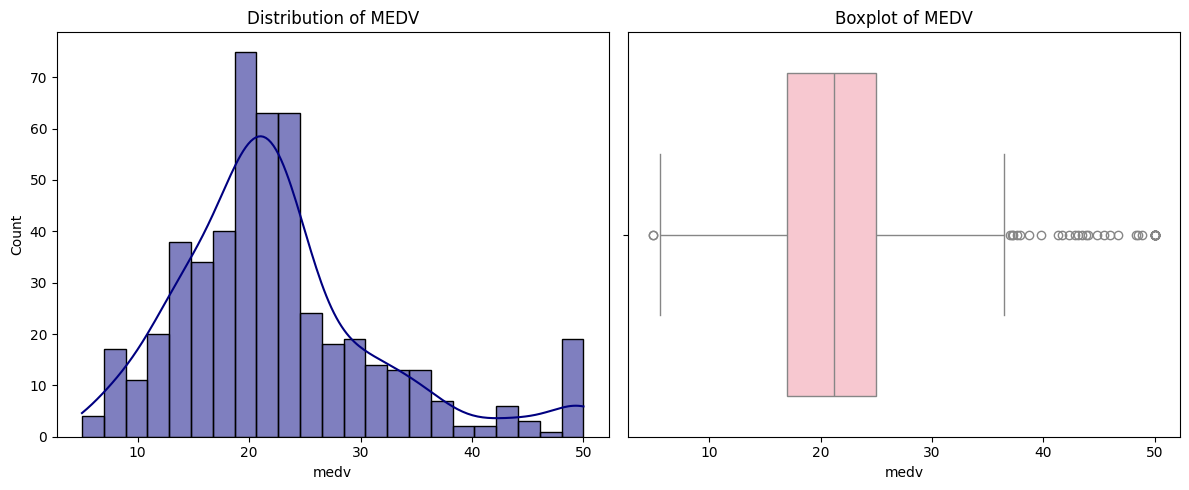

In [180]:
# medv 분포 및 이상치 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['medv'], kde=True, color='navy')
plt.title('Distribution of MEDV')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['medv'], color='pink')
plt.title('Boxplot of MEDV')

plt.tight_layout()
plt.show()

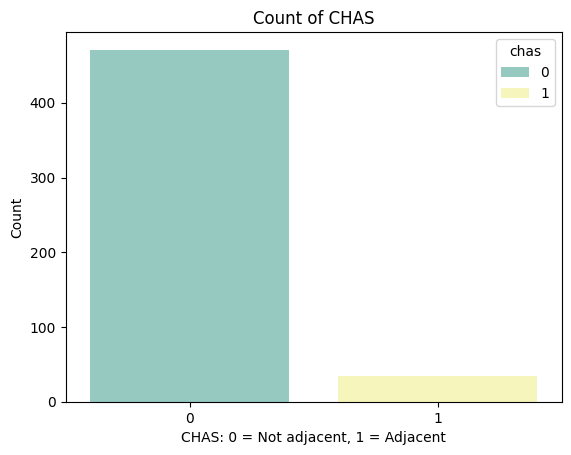

In [181]:
# 찰스강 인접 여부의 데이터 개수 확인
sns.countplot(data=df,
    x='chas',
    hue='chas',
    palette='Set3',
)

plt.title('Count of CHAS')
plt.xlabel('CHAS: 0 = Not adjacent, 1 = Adjacent')
plt.ylabel('Count')
plt.show()

In [182]:
# 가설:

# 대립가설: 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 있다.
# 귀무가설: 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 없다.

# 찰스강 인접 지역
chas_yes_group = df[df['chas'] == 1]['medv']

# 찰스강 비인접 지역
chas_no_group = df[df['chas'] == 0]['medv']


# 두 집단간의 등분산성 검정
_, p_value = stats.levene(chas_yes_group, chas_no_group)
print(f'p_value : {p_value:.4f}')

p_value : 0.0326


In [183]:
# 레빈 검정 결과 p_value가 0.05보다 작으므로 등분산성이 성립되지 않는다.
# p-value < 0.05

# 두 집단은 독립된 집단이고,
# 등분산성이 성립하지 않으므로 Welch t-test 수행
_, p_value = stats.ttest_ind(chas_yes_group, chas_no_group, equal_var=False)
print(f'p_value : {p_value:.4f}')

p_value : 0.0036


In [184]:
# 검정 결과 p_value가 0.05 보다 작게 나왔으므로 귀무가설을 기각하고 대립가설을 채택할 수 있다.
# 이에, 찰스강 인접 지역과 찰스강 비인접 지역간의 주택가격 중앙값 평균 차이는 통계적으로 유의미하다고 볼 수 있다.

# 두 집단의 주택가격 중앙값 평균

# 찰스강 인접 지역
mean_yes = np.mean(chas_yes_group)

# 찰스강 비인접 지역
mean_no = np.mean(chas_no_group)

print(f'찰스강 인접 지역 평균 : {mean_yes:.4f}')
print(f'찰스강 비인접 지역 평균 : {mean_no:.4f}')
print(f'평균 차이 : {mean_yes - mean_no:.4f}')

찰스강 인접 지역 평균 : 28.4400
찰스강 비인접 지역 평균 : 22.0938
평균 차이 : 6.3462


In [185]:
# Boston Housing 데이터는 모든 컬럼이 이미 숫자형이므로
# 별도의 범주형 데이터에 대한 인코딩을 하지 않는다.
df_encoded = df.astype(float)

df_encoded

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


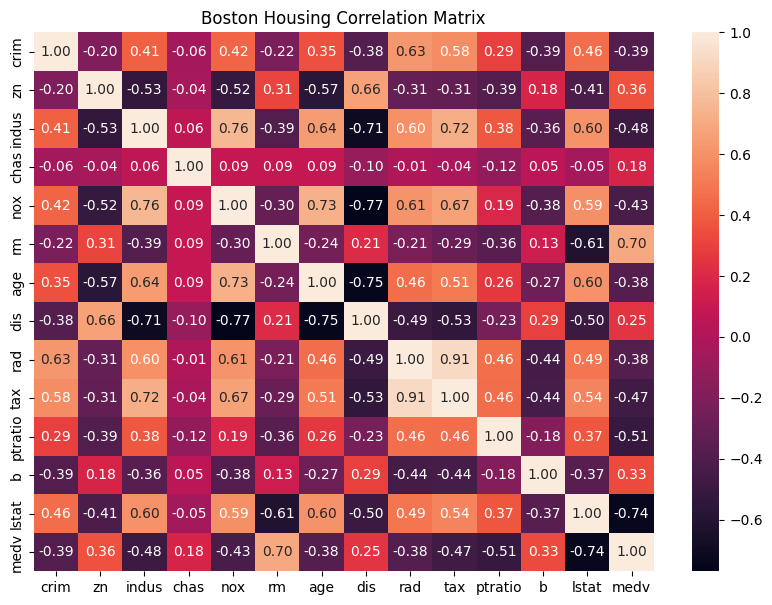

In [186]:
# 피어슨 상관계수 계산
corr_matrix = df_encoded.corr()

# 히트맵 시각화
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
)

plt.title('Boston Housing Correlation Matrix')
plt.show()

In [187]:
# 독립변수와 종속변수 분리
X = df_encoded.drop('medv', axis=1)
y = df_encoded['medv']

# 상수항 추가
X_with_constant = sm.add_constant(X)

# OLS 모델 생성 및 학습
ols_model = sm.OLS(y, X_with_constant)
ols_results = ols_model.fit()

# 회귀분석 결과 출력
ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          6.72e-135
Time:                        03:09:45   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.000      26.432      46.487
crim          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
zn             0.0464      0.014      3.382      0.001       0.019       0.073
indus          0.0206      0.061      0.334      0.738      -0.100       0.141
chas           2.6867      0.862      3.118      0.002       0.994       4.380
nox          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
rm             3.8099      0.418      9.116      0.000       2.989       4.631
age            0.0007      0.013      0.052      0.958      -0.025       0.027
dis           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
rad            0.3060      0.066      4.613      0.000       0.176       0.436
tax           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
ptratio       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
b              0.0093      0.003      3.467      0.001       0.004       0.015
lstat         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [188]:
# 독립변수와 종속변수 분리
X = df_encoded.drop('medv', axis=1)
y = df_encoded['medv']

# 상수항 추가
X_with_constant = sm.add_constant(X)

# p-value가 0.05보다 큰 변수 제거
X_with_constant = X_with_constant.drop(
    ['age', 'indus'],
    axis=1
)

# OLS 모델 생성 및 학습
ols_model = sm.OLS(y, X_with_constant)
ols_results = ols_model.fit()

# 결과 출력
ols_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     128.2
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          5.54e-137
Time:                        03:09:45   Log-Likelihood:                -1498.9
No. Observations:                 506   AIC:                             3022.
Df Residuals:                     494   BIC:                             3072.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.3411      5.067      7.171      0.000      26.385      46.298
crim          -0.1084      0.033     -3.307      0.001      -0.173      -0.044
zn             0.0458      0.014      3.390      0.001       0.019       0.072
chas           2.7187      0.854      3.183      0.002       1.040       4.397
nox          -17.3760      3.535     -4.915      0.000     -24.322     -10.430
rm             3.8016      0.406      9.356      0.000       3.003       4.600
dis           -1.4927      0.186     -8.037      0.000      -1.858      -1.128
rad            0.2996      0.063      4.726      0.000       0.175       0.424
tax           -0.0118      0.003     -3.493      0.001      -0.018      -0.005
ptratio       -0.9465      0.129     -7.334      0.000      -1.200      -0.693
b              0.0093      0.003      3.475      0.001       0.004       0.015
lstat         -0.5226      0.047    -11.019      0.000      -0.616      -0.429
==============================================================================
Omnibus:                      178.430   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              787.785
Skew:                           1.523   Prob(JB):                    8.60e-172
Kurtosis:                       8.300   Cond. No.                     1.47e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [189]:
## 분석 보고서

# 모든 요인들이 0일 때 주택가격 중앙값은 36.3411이 된다.

# crim은 다른 요인들이 통제되었을 때 crim이 1 증가할 때, 주택가격 중앙값 변화량은 -0.1084가 된다.

# zn은 다른 요인들이 통제되었을 때 zn이 1 증가할 때, 주택가격 중앙값 변화량은 0.0458이 된다.

# chas는 연속형 변수가 아니라 0, 1로 표현된 범주형 변수이므로,
# chas는 다른 요인들이 통제되었을 때 찰스강에 인접하지 않은 지역에 비해, 찰스강에 인접한 지역의 주택가격 중앙값이 2.7187 즉, 2,718.7달러 높게 나타난다.

# nox는 다른 요인들이 통제되었을 때 nox가 1 증가할 때, 주택가격 중앙값 변화량은 -17.3760이 된다.

# medv의 단위가 1,000달러이므로,
# rm은 다른 요인들이 통제되었을 때 평균 방의 수가 1개 증가할 때, 주택가격 중앙값 변화량은 3.8016 즉, 3,801.6달러 증가 한다.

# dis는 다른 요인들이 통제되었을 때 dis가 1 증가할 때, 주택가격 중앙값 변화량은 -1.4927이 된다.

# rad는 다른 요인들이 통제되었을 때 rad가 1 증가할 때, 주택가격 중앙값 변화량은 0.2996이 된다.

# tax는 다른 요인들이 통제되었을 때 tax가 1 증가할 때, 주택가격 중앙값 변화량은 -0.0118이 된다.

# ptratio는 다른 요인들이 통제되었을 때 학생-교사 비율이 1 증가할 때, 주택가격 중앙값 변화량은 -0.9465가 된다.

# b는 다른 요인들이 통제되었을 때 b가 1 증가할 때, 주택가격 중앙값 변화량은 0.0093이 된다.

# lstat은 다른 요인들이 통제되었을 때 lstat이 1 증가할 때, 주택가격 중앙값 변화량은 -0.5226이 된다.

In [190]:
# 예측 작업 수행
# 회귀 분석을 통해서 p value가 0.05 이상이 나온 컬럼들을 제외한 나머지 컬럼들만 사용한다.
selected_features = df_encoded.drop(['age', 'indus'], axis=1)

# 독립변수와 종속변수로 나눈다.
X = selected_features.drop('medv', axis=1)
y = selected_features['medv']

# 학습용과 검증용으로 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [191]:
# 학습
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [192]:
# 예측
pred = lr_model.predict(X_test)
pred

array([29.29030158, 35.89200644, 14.68092966, 24.63470222, 18.77052611,
       23.22916899, 17.74649276, 14.09962882, 22.99216313, 20.78328515,
       24.89585879, 18.81885273, -5.99779068, 21.60883557, 19.38674281,
       25.99483154, 20.08333849,  5.8746336 , 40.44980506, 17.655194  ,
       26.96423078, 29.88447196, 11.57316424, 24.06299419, 17.91898849,
       15.89136784, 22.56241947, 14.6057001 , 22.55558877, 19.31149405,
       22.79110958, 25.19430821, 25.88731073, 17.85048448, 16.76622966,
       16.93247686, 31.20814361, 20.13746474, 23.68659364, 24.2032595 ,
       14.06725586, 32.40376611, 42.47778575, 17.34163628, 27.48472315,
       17.06238847, 14.3259464 , 25.46693384, 20.23082558, 30.24491638,
       21.464095  , 34.2602216 , 16.2426369 , 26.33655703, 39.55419656,
       22.33968675, 18.90911346, 32.53823385, 25.0880256 , 13.06422274,
       22.62770143, 30.35960647, 31.34652156, 15.85174921, 20.44157951,
       16.89757068, 20.54230674, 25.9024268 , 30.50910954, 11.64

In [193]:
# R2 : 회귀모델의 설명력
# 예측 때는 0.8 이상을 권장한다.
# 만약 낮으면 다른 요인 변수들을 발굴해야 한다.
r2 = r2_score(y_test, pred)
print(f'r2 : {r2}')

# mean absolute error : 오차의 절댓값에 대한 평균
mae = mean_absolute_error(y_test, pred)
print(f'mae : {mae}')

# mean squared error : 오차의 제곱에 대한 평균
# 보고서 작성시 사용하지 않으나, 해당 보고서에서는 회귀 분석이나 딥러닝, 머신러닝에서 최적의 상수값을 찾기 위한 오차 계산용으로 사용함.
mse = mean_squared_error(y_test, pred)
print(f'mse(참고용) : {mse}')

# RMSE : MSE에 제곱근을 적용한 값
# medv와 같은 단위이면서 큰 오차에 더 민감하다.
rmse = np.sqrt(mse)
print(f'rmse : {rmse}')

# mae를 중심적으로 참고하길 권장함.

r2 : 0.6715231799608938
mae : 3.1496942855296197
mse(참고용) : 24.08844789394024
rmse : 4.907998359203092


In [194]:
# 최종 보고서 작성을 위한 가설검정 결과
# 두 집단의 분산이 동일하지 않으므로 Welch의 독립표본 t 검정을 수행한다.
t_statistic, ttest_p_value = stats.ttest_ind(
    chas_yes_group,
    chas_no_group,
    equal_var=False
)


# 유의수준 0.05를 기준으로 가설검정 결과를 작성한다.
if ttest_p_value < 0.05:
    hypothesis_result = """
찰스강 인접 여부에 따른 주택가격 중앙값 차이에 대한 검정 결과, p-value가 0.05보다 작으므로 귀무가설을 기각한다.
따라서 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 있다고 판단한다.
"""
else:
    hypothesis_result = """
찰스강 인접 여부에 따른 주택가격 중앙값 차이에 대한 검정 결과, p-value가 0.05보다 크므로 귀무가설을 기각하지 못한다.
따라서 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에 통계적으로 유의미한 차이가 있다고 보기 어렵다.
"""


# 회귀분석 결과에서 통계적으로 유의미한 변수만 추출한다.
# const는 현실적인 해석이 어렵기 때문에 영향력 분석에서 제외한다.
coefficient = ols_results.params.drop('const')
coefficient_pvalue = ols_results.pvalues.drop('const')

significant_coefficient = coefficient[
    coefficient_pvalue < 0.05
]


# 회귀계수가 양수이면 주택가격 상승 요인,
# 음수이면 주택가격 하락 요인으로 구분한다.
positive_factors = significant_coefficient[
    significant_coefficient > 0
]

negative_factors = significant_coefficient[
    significant_coefficient < 0
]


# 변수 이름을 보고서에서 사용할 한글 표현으로 변경한다.
factor_names = {
    'crim': '지역별 1인당 범죄율(crim)',
    'zn': '넓은 주거용 토지 비율(zn)',
    'chas': '찰스강 인접 여부(chas)',
    'nox': '질소산화물 농도(nox)',
    'rm': '주택당 평균 방의 수(rm)',
    'dis': '고용센터까지의 가중 거리(dis)',
    'rad': '고속도로 접근성 지수(rad)',
    'tax': '재산세율(tax)',
    'ptratio': '학생-교사 비율(ptratio)',
    'b': 'B 지수(b)',
    'lstat': '저소득층 인구 비율(lstat)'
}


# 상승 요인에 대한 문장 생성
positive_report = []

for variable, coef in positive_factors.items():

    if variable == 'chas':
        sentence = (
            f"- {factor_names[variable]}: 다른 요인들이 통제되었을 때 찰스강 인접 지역은 비인접 지역보다 주택가격 중앙값이 약 {coef:.4f}, 즉 약 {coef * 1000:,.1f}달러 높은 것으로 나타났다."
        )

    else:
        sentence = (
            f"- {factor_names.get(variable, variable)}: 다른 요인들이 통제되었을 때 해당 변수가 1 증가하면 주택가격 중앙값은 약 {coef:.4f}, 즉 약 {coef * 1000:,.1f}달러 증가하는 것으로 나타났다."
        )

    positive_report.append(sentence)


# 하락 요인에 대한 문장 생성
negative_report = []

for variable, coef in negative_factors.items():

    sentence = (
        f"- {factor_names.get(variable, variable)}: 다른 요인들이 통제되었을 때 해당 변수가 1 증가하면 주택가격 중앙값은 약 {abs(coef):.4f}, 즉 약 {abs(coef) * 1000:,.1f}달러 감소하는 것으로 나타났다."
    )

    negative_report.append(sentence)


# 리스트에 저장된 문장들을 하나의 문자열로 연결한다.
positive_report = '\n'.join(positive_report)
negative_report = '\n'.join(negative_report)

In [195]:
print(f"""
최종 데이터 분석 및 회귀분석 보고서


1. 분석 목적

본 분석은 Boston Housing 데이터를 이용하여 찰스강 인접 여부에 따라 주택가격 중앙값에 차이가 있는지를 검정하고, 주택가격의 상승과 하락에 관련된 요인을 파악하기 위해 수행하였다.


2. 가설검정 결과

대립가설: 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 있다.

귀무가설: 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 없다.

Welch 독립표본 t 검정의 p-value는 {ttest_p_value:.4f}로 나타났다.

{hypothesis_result}


3. 회귀모형의 설명력

처음 회귀분석을 수행했을 때 indus와 age의 p-value가 유의수준 0.05보다 크게 나타났다.

이에 따라 두 변수를 제거한 뒤 회귀분석을 다시 수행하였다.

수정된 회귀모형의 R-squared는 약 {ols_results.rsquared:.3f}으로 나타났다.

따라서 현재 독립변수들이 주택가격 중앙값 변화의 약 {ols_results.rsquared * 100:.1f}%를 설명한다고 볼 수 있다.

독립변수의 개수를 고려한 Adj. R-squared는 약 {ols_results.rsquared_adj:.3f}으로 나타났다.

따라서 독립변수의 개수를 고려했을 때 수정된 회귀모형은 주택가격 중앙값 변화의 약 {ols_results.rsquared_adj * 100:.1f}%를 설명하는 것으로 나타났다.


4. 주택가격 상승 요인

medv는 주택가격 중앙값을 의미하며, 단위는 1,000달러이다.

다음 변수들은 다른 요인들을 통제한 상태에서 주택가격 중앙값과 통계적으로 유의한 양의 관계를 보였다.

{positive_report}


5. 주택가격 하락 요인

다음 변수들은 다른 요인들을 통제한 상태에서 주택가격 중앙값과 통계적으로 유의한 음의 관계를 보였다.

{negative_report}


6. 예측모형 평가 결과

테스트 데이터를 이용한 예측 결과 R2는 약 {r2:.3f}으로 나타났다.

따라서 해당 회귀모형은 테스트 데이터의 주택가격 중앙값 변화를 약 {r2 * 100:.1f}% 설명한다고 볼 수 있다.

MAE는 약 {mae:.3f}으로 나타났다.

따라서 모델의 예측값은 실제 주택가격 중앙값과 평균적으로 약 {mae:.3f} 정도의 오차가 발생한다고 볼 수 있다.

주택가격 중앙값의 단위가 1,000달러이므로 실제 금액으로는 평균적으로 약 {mae * 1000:,.0f}달러의 예측 오차가 발생한다.

MSE는 약 {mse:.3f}으로 나타났다.

MSE는 예측 오차를 제곱하여 계산하기 때문에 단위도 제곱되며, 실제 금액 단위로 직접 해석하기보다는 모형의 오차를 비교하기 위한 참고 지표로 사용할 수 있다.

RMSE는 약 {rmse:.3f}으로 나타났다.

RMSE는 종속변수인 medv와 단위가 같으므로 실제 금액으로는 약 {rmse * 1000:,.0f}달러에 해당한다.

RMSE가 MAE보다 크게 나타났으므로 일부 관측값에서 상대적으로 큰 예측 오차가 발생했을 가능성이 있다.


7. 종합 결론

Welch 독립표본 t 검정 결과 p-value는 {ttest_p_value:.4f}로 유의수준 0.05보다 작게 나타났다.

따라서 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에 차이가 없다는 귀무가설을 기각하였다.

즉, 찰스강 인접 여부에 따른 주택가격 중앙값의 평균 차이는 통계적으로 유의미한 것으로 판단하였다.

또한 다중회귀분석을 통해 다른 요인들을 통제한 상태에서도 각 독립변수가 주택가격 중앙값과 양의 관계를 보이는지 또는 음의 관계를 보이는지를 확인하였다.

회귀분석 결과 zn, chas, rm, rad, b는 주택가격 중앙값과 통계적으로 유의한 양의 관계를 보였다.

반면 crim, nox, dis, tax, ptratio, lstat은 주택가격 중앙값과 통계적으로 유의한 음의 관계를 보였다.

특히 다른 조건이 같을 때 주택당 평균 방의 수가 많거나 찰스강에 인접한 지역일수록 주택가격 중앙값이 높게 나타나는 경향이 있었다.

반면 저소득층 비율, 학생-교사 비율, 질소산화물 농도 등이 높아질수록 주택가격 중앙값이 낮게 나타나는 경향이 있었다.

다만 회귀계수는 변수마다 측정 단위가 다르므로, 회귀계수의 절댓값만으로 어떤 변수가 가장 큰 영향력을 가진다고 단순 비교해서는 안 된다.

또한 본 분석 결과는 변수 간의 통계적 관련성을 나타내며, 특정 변수가 주택가격 변화의 직접적인 원인임을 확정하는 결과는 아니다.
""")


최종 데이터 분석 및 회귀분석 보고서


1. 분석 목적

본 분석은 Boston Housing 데이터를 이용하여 찰스강 인접 여부에 따라 주택가격 중앙값에 차이가 있는지를 검정하고, 주택가격의 상승과 하락에 관련된 요인을 파악하기 위해 수행하였다.


2. 가설검정 결과

대립가설: 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 있다.

귀무가설: 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 없다.

Welch 독립표본 t 검정의 p-value는 0.0036로 나타났다.


찰스강 인접 여부에 따른 주택가격 중앙값 차이에 대한 검정 결과, p-value가 0.05보다 작으므로 귀무가설을 기각한다.
따라서 찰스강 인접 여부에 따라 주택가격 중앙값의 평균에는 통계적으로 유의미한 차이가 있다고 판단한다.



3. 회귀모형의 설명력

처음 회귀분석을 수행했을 때 indus와 age의 p-value가 유의수준 0.05보다 크게 나타났다.

이에 따라 두 변수를 제거한 뒤 회귀분석을 다시 수행하였다.

수정된 회귀모형의 R-squared는 약 0.741으로 나타났다.

따라서 현재 독립변수들이 주택가격 중앙값 변화의 약 74.1%를 설명한다고 볼 수 있다.

독립변수의 개수를 고려한 Adj. R-squared는 약 0.735으로 나타났다.

따라서 독립변수의 개수를 고려했을 때 수정된 회귀모형은 주택가격 중앙값 변화의 약 73.5%를 설명하는 것으로 나타났다.


4. 주택가격 상승 요인

medv는 주택가격 중앙값을 의미하며, 단위는 1,000달러이다.

다음 변수들은 다른 요인들을 통제한 상태에서 주택가격 중앙값과 통계적으로 유의한 양의 관계를 보였다.

- 넓은 주거용 토지 비율(zn): 다른 요인들이 통제되었을 때 해당 변수가 1 증가하면 주택가격 중앙값은 약 0.0458, 즉 약 45.8달러 증가하는 것으로 나타났다.
- 찰스강 인접 여부(chas): 다른 요인들이 통제되었을 때 찰스강 인접